In [1]:
import pandas as pd
from gplearn.genetic import SymbolicRegressor, SymbolicTransformer, SymbolicClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import seaborn as sns


In [2]:
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_excel("./dados para machine learning_r02.xlsx", 
                   "Dataset com TS variável MC2020", decimal=',') 
df

,Autor,Diâmetro da armadura (mm),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto (MPa),Cobrimento (mm),Distância ao centro de gravidade da armadura (mm),Largura da viga - b (mm),Altura da viga - h (mm),Área de aço tracionada - As (mm2),...,Linha neutra no Estádio II - XII (mm),Taxa de armadura,Momento fletor - Ms (kNm),Tensão na armadura menos tension stiffening (MPa),w (mm),modelo 3,modelo 4,modelo 5,erro modelo 3,predict
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,57.361777,0.021300,20.800,120.527746,0.16,0.197683,0.194934,0.163168,-0.037683,NaN
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,57.361777,0.021300,27.300,223.847983,0.23,0.289641,0.287565,0.263762,-0.059641,NaN
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,57.361777,0.021300,28.200,242.052198,0.24,0.303957,0.302037,0.277691,-0.063957,NaN
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,57.361777,0.021300,32.600,325.147190,0.27,0.364664,0.363540,0.345785,-0.094664,NaN
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,57.361777,0.021300,41.200,447.784457,0.35,0.444272,0.444465,0.478879,-0.094272,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,NaN,28.7,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,...,196.926616,0.046242,149.268,213.143867,0.19,0.259077,0.263736,0.250166,-0.069077,NaN
337,NaN,28.7,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,...,196.926616,0.046242,168.882,245.038321,0.22,0.282354,0.287873,0.282278,-0.062354,NaN
338,Viga 23-6-11-2 - Clark (1956),35.8,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,...,231.967079,0.067478,167.034,150.918822,0.17,0.207484,0.217745,0.181871,-0.037484,NaN
339,Viga 23-6-11-3 - Clark (1956),35.8,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,...,228.699801,0.067478,130.788,108.349173,0.19,0.169117,0.176834,0.134286,0.020883,NaN


In [4]:
X = df.drop(columns=['Autor', 'w (mm)', 'modelo 3', 'modelo 4', 'modelo 5', 'erro modelo 3', 'predict'])
y = df['erro modelo 3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {len(X_train)} samples")
print(f"Tamanho do teste: {len(X_test)} samples")
print(X_train.shape, X_test.shape)

Tamanho do treino: 272 samples
Tamanho do teste: 69 samples
(272, 14) (69, 14)


In [5]:
model_gp = SymbolicRegressor(
    population_size=2000,
    generations=70,
    stopping_criteria=0.01,
    function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'sin', 'cos','tan'),
    p_crossover=0.7,
    p_point_mutation=0.2,
    verbose=1
)
#----------------------------
# function_set = ['add', 'sub', 'mul', 'div',
#                 'sqrt', 'log', 'abs', 'neg', 'inv',
#                 'max', 'min']

# gp = SymbolicTransformer(generations=20, population_size=2000,
#                         hall_of_fame=100, n_components=10,
#                         function_set=function_set,
#                         parsimony_coefficient=0.0005,
#                         max_samples=0.9, verbose=1,
#                         random_state=0, n_jobs=3)
#----------------------------

In [6]:
#model_gp.fit(X_train, y_train)
model_gp.fit(X_train, y_train)
y_pred = model_gp.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"----------------------------------------------------------------------------------------------------")
print(f"GPLearn: R² = {r2:.4f}")

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0     8.56           629864        4        0.0640882              N/A     20.69s
   1     7.96          20801.5        7        0.0620409              N/A     21.94s
   2     3.71          1110.02        4         0.059369              N/A     20.21s
   3     3.89           155.64        4         0.059369              N/A     19.74s
   4     2.28            14.74        4         0.059369              N/A     19.19s
   5     3.29          26.9875        4         0.059369              N/A     19.56s
   6     3.97          7.44754        4         0.059369              N/A     19.27s
   7     3.97          3.19807        4         0.059369              N/A     21.86s
   8     3.96          3.12866        4         0.059369              N/A  

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from gplearn.genetic import SymbolicRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_excel('machine_learning_r02.xlsx')

X = df.drop(columns=['Autor', 'w (mm)', 'modelo 3', 'modelo 4', 'modelo 5', 'erro modelo 3', 'predict'])
y = df['erro modelo 3']

numerical_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

X_scaled_np = X_scaled.values
y_np = y.to_numpy()


X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_scaled_np, y_np, test_size=0.3, random_state=42
)

print(f"Dados preparados: {len(X_treino)} amostras de treino, {len(X_teste)} amostras de teste.")

print("\nIniciando treinamento do SymbolicRegressor...")

model_gp = SymbolicRegressor(
    population_size=5000,
    generations=30,
    stopping_criteria=0.01,
    function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'sin', 'cos'),
    p_crossover=0.7,
    p_point_mutation=0.2,
    verbose=1,
    random_state=42
)

model_gp.fit(X_treino, y_treino)

print("\nTreinamento concluído.")
print("Melhor programa (fórmula) encontrado:")
print(model_gp._program)

y_pred_treino = model_gp.predict(X_treino)
mse_treino = mean_squared_error(y_treino, y_pred_treino)
r2_treino = r2_score(y_treino, y_pred_treino)

print(f"\n--- Desempenho nos dados de TREINO ---")
print(f"MSE Treino: {mse_treino:.4f}")
print(f"R² Treino: {r2_treino:.4f}")

y_pred_teste = model_gp.predict(X_teste)
mse_teste = mean_squared_error(y_teste, y_pred_teste)
r2_teste = r2_score(y_teste, y_pred_teste)

print(f"\n--- Desempenho nos dados de TESTE (O RESULTADO REAL) ---")
print(f"MSE Teste: {mse_teste:.4f}")
print(f"R² Teste: {r2_teste:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'machine_learning_r02.xlsx'

In [ ]:
display(pd.DataFrame(y_test).describe())
display(pd.DataFrame(y_pred).describe())

,erro modelo 3
count,69.000000
mean,0.009736
std,0.099984
min,-0.149800
25%,-0.047987
50%,-0.017923
75%,0.057957
max,0.334901


,0
count,69.000000
mean,-0.007236
std,0.046049
min,-0.067953
25%,-0.056890
50%,0.000000
75%,0.016218
max,0.099060


In [ ]:
dados_dicionario = {
    'y_test': y_test,
    'y_pred': y_pred
}

df_completo = pd.DataFrame(dados_dicionario)

display(df_completo)

,y_test,y_pred
322,-0.047987,0.000000
116,-0.044565,0.014702
113,-0.061412,0.014702
42,0.112712,0.053427
126,0.090490,0.016218
223,-0.149800,-0.061122
182,-0.110495,0.000000
179,-0.087845,0.000000
338,-0.037484,-0.048182
25,0.093848,0.048864


0.1653261631434665


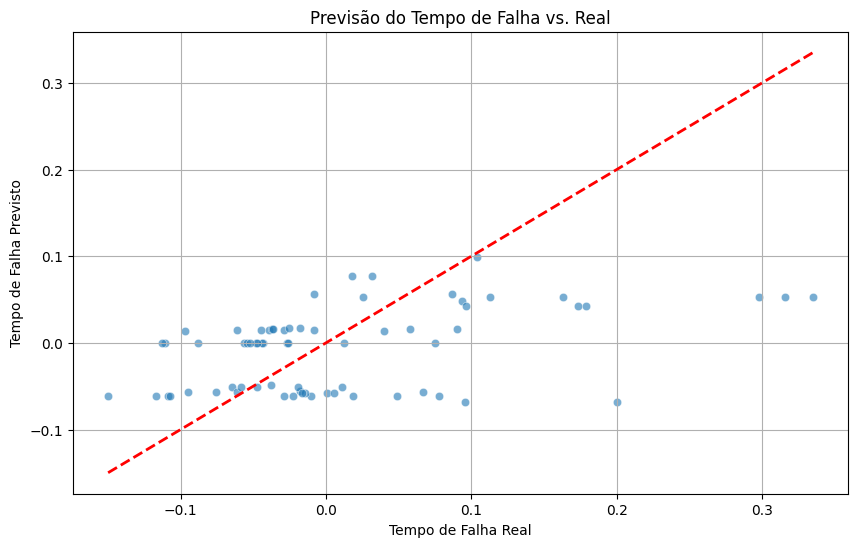

In [ ]:
r2 = r2_score(y_test, y_pred)
print(r2)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Tempo de Falha Real')
plt.ylabel('Tempo de Falha Previsto')
plt.title('Previsão do Tempo de Falha vs. Real')
plt.grid(True)
plt.show()

In [ ]:
print(model_gp._program)

div(log(div(X3, X13)), X6)


In [ ]:
dot_data = model_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
dot_data

'digraph program {\nnode [style=filled]\n0 [label="div", fillcolor="#136ed4"] ;\n1 [label="-0.056", fillcolor="#60a6f6"] ;\n2 [label="X1", fillcolor="#60a6f6"] ;\n0 -> 2 ;\n0 -> 1 ;\n}'